In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve,
                               accuracy_score, precision_score, recall_score, f1_score,
                               roc_auc_score, ConfusionMatrixDisplay)
import os

X_train = pd.read_csv("../data/interim/X_train.csv")
X_test = pd.read_csv("../data/interim/X_test.csv")
y_train = pd.read_csv("../data/interim/y_train.csv").squeeze()
y_test = pd.read_csv("../data/interim/y_test.csv").squeeze()

RANDOM_SEED = 42
model = HistGradientBoostingClassifier(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model refit. Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

Model refit. Test accuracy: 0.9007
Test ROC-AUC: 0.9701


Confusion Matrix:
[[4908  648]
 [ 488 5396]]

True Negatives:  4908
False Positives: 648
False Negatives: 488
True Positives:  5396


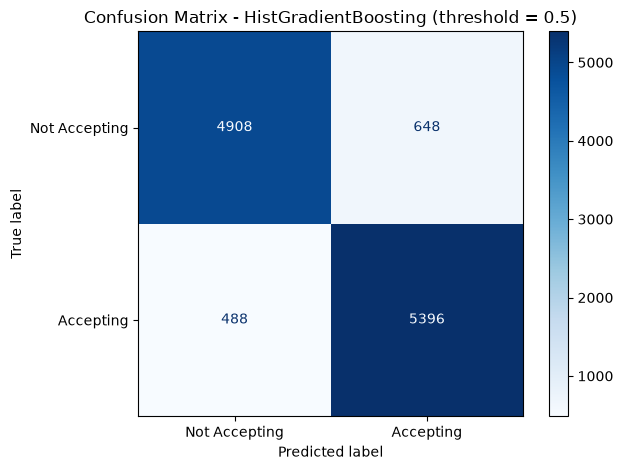

In [2]:
os.makedirs("../reports/figures", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Accepting", "Accepting"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - HistGradientBoosting (threshold = 0.5)")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150)
plt.show()

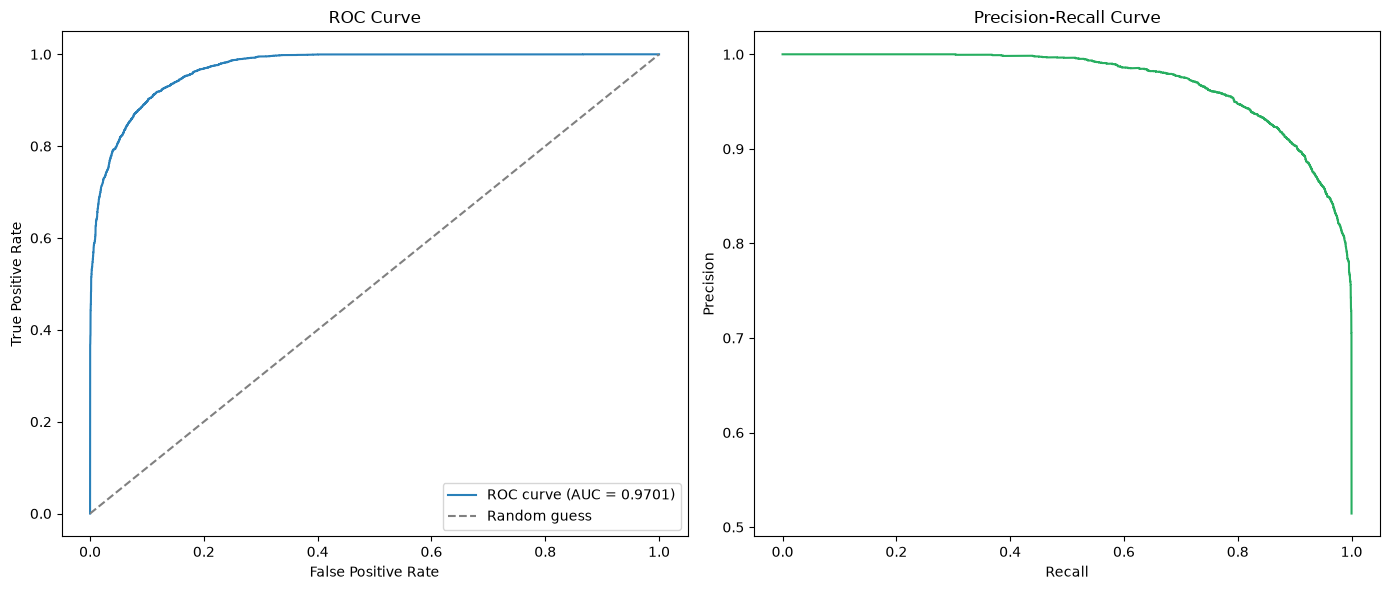

In [3]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color="#2980b9", label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall_vals, precision_vals, color="#27ae60")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("../reports/figures/roc_pr_curves.png", dpi=150)
plt.show()

Top 15 most important features:
                                                feature  importance_mean  importance_std
                                            tenure_days         0.144178        0.002605
    supply_Blood Glucose Monitors/Supplies (Mail Order)         0.124336        0.002116
                                               state_NY         0.020927        0.000791
                                 supply_Ostomy Supplies         0.020192        0.001150
                                  specialty_Optometrist         0.010035        0.000702
                                 supply_Limb Prostheses         0.006538        0.000338
                                               latitude         0.005962        0.000707
                                              longitude         0.005385        0.000644
                         supply_Orthoses: Off-The-Shelf         0.004371        0.000869
                                     specialty_Optician         0.002937      

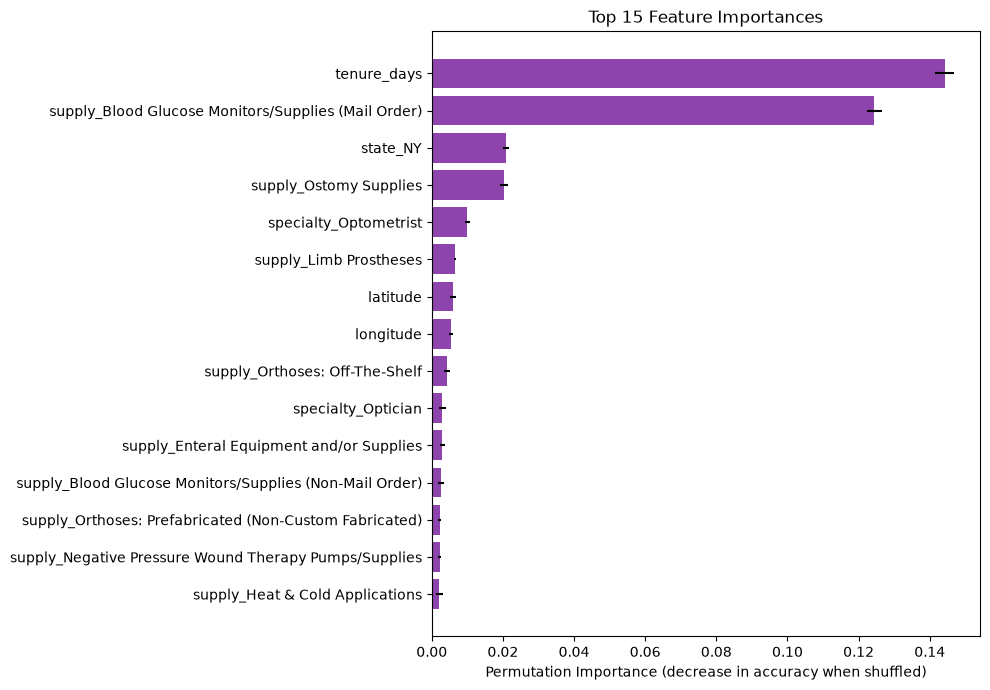

In [4]:
from sklearn.inspection import permutation_importance

# Using a sample for speed - permutation importance is expensive on the full test set
perm_result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=RANDOM_SEED, n_jobs=-1)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15).to_string(index=False))

top15 = importance_df.head(15)
plt.figure(figsize=(10, 7))
plt.barh(top15["feature"], top15["importance_mean"], xerr=top15["importance_std"], color="#8e44ad")
plt.xlabel("Permutation Importance (decrease in accuracy when shuffled)")
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150)
plt.show()

## Which Metric Matters Most for This Business Problem

Accuracy alone is not the right lens for this project because Case 1 and Case 2 have different 
cost structures for errors:

- **Case 1** (identifying high-risk, low-acceptance states) is harmed more by **false negatives** — 
  a genuinely low-acceptance provider that the model misses never gets flagged for outreach, and the 
  access gap goes unaddressed. **Recall** matters most here.
- **Case 2** (targeting high-predicted-probability providers for outreach) is harmed more by 
  **false positives** — spending outreach budget on a provider the model wrongly flagged as likely 
  to convert wastes real resources. **Precision** matters most here.

ROC-AUC was used to select the model overall because it balances both error types fairly across 
all thresholds without picking a side prematurely. But once the model is applied to Case 2's specific 
outreach segment (probability > 0.70), **precision at that threshold becomes the operationally 
relevant metric**, since every provider in that segment represents real spend. This is why threshold 
selection (next section) is evaluated on precision/recall trade-offs, not on accuracy.

In [9]:
print("Current model at default threshold (0.5):")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print()
print("This means: of providers the model predicts as 'Accepting', "
      f"{precision_score(y_test, y_pred)*100:.1f}% actually are.")
print("Of providers who actually accept, the model correctly identifies "
      f"{recall_score(y_test, y_pred)*100:.1f}% of them.")

Current model at default threshold (0.5):
Precision: 0.8928
Recall: 0.9171

This means: of providers the model predicts as 'Accepting', 89.3% actually are.
Of providers who actually accept, the model correctly identifies 91.7% of them.


In [10]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
threshold_results = []

for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": round(precision_score(y_test, y_pred_t), 4),
        "recall": round(recall_score(y_test, y_pred_t), 4),
        "f1": round(f1_score(y_test, y_pred_t), 4),
        "flagged_as_accepting": int(y_pred_t.sum()),
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))


 threshold  precision  recall     f1  flagged_as_accepting
       0.3     0.8294  0.9735 0.8957                  6906
       0.4     0.8607  0.9485 0.9025                  6484
       0.5     0.8928  0.9171 0.9048                  6044
       0.6     0.9198  0.8732 0.8959                  5586
       0.7     0.9447  0.8098 0.8721                  5044
       0.8     0.9703  0.7276 0.8316                  4412


In [11]:
print("Threshold validation conclusion:")
print("- F1 is maximized at the default threshold (0.5), confirming it as a reasonable general-purpose cutoff.")
print("- At threshold 0.7 (the cutoff specified in Case 2's segment definition), precision reaches 94.47%,")
print("  meaning providers flagged in that segment are highly likely to be genuine candidates, not false alarms.")
print("- Case 1 (identifying at-risk providers) should rely on continuous predicted probability rather than")
print("  a single hard threshold, since higher thresholds trade away recall - the goal there is not to miss")
print("  genuinely at-risk providers.")
print("- Decision: keep 0.5 as the default classification threshold for general reporting (Predicted_Class),")
print("  but Case 2's specific segment will continue to use the 0.70 cutoff as originally specified, now")
print("  validated as producing high precision (94.47%) rather than assumed arbitrarily.")

Threshold validation conclusion:
- F1 is maximized at the default threshold (0.5), confirming it as a reasonable general-purpose cutoff.
- At threshold 0.7 (the cutoff specified in Case 2's segment definition), precision reaches 94.47%,
  meaning providers flagged in that segment are highly likely to be genuine candidates, not false alarms.
- Case 1 (identifying at-risk providers) should rely on continuous predicted probability rather than
  a single hard threshold, since higher thresholds trade away recall - the goal there is not to miss
  genuinely at-risk providers.
- Decision: keep 0.5 as the default classification threshold for general reporting (Predicted_Class),
  but Case 2's specific segment will continue to use the 0.70 cutoff as originally specified, now
  validated as producing high precision (94.47%) rather than assumed arbitrarily.


In [12]:
# Attach predictions back to test set for inspection
X_test_review = X_test.copy()
X_test_review["actual"] = y_test.values
X_test_review["predicted"] = y_pred
X_test_review["predicted_probability"] = y_proba

false_positives = X_test_review[(X_test_review["actual"] == 0) & (X_test_review["predicted"] == 1)]
false_negatives = X_test_review[(X_test_review["actual"] == 1) & (X_test_review["predicted"] == 0)]

print("False Positives (predicted Accepting, actually Not Accepting):", len(false_positives))
print("Average predicted probability among false positives:", round(false_positives["predicted_probability"].mean(), 4))
print()
print("False Negatives (predicted Not Accepting, actually Accepting):", len(false_negatives))
print("Average predicted probability among false negatives:", round(false_negatives["predicted_probability"].mean(), 4))
print()
print("Interpretation: false positives with high average probability suggest the model is confidently")
print("wrong on some providers - worth flagging as a limitation rather than treating every high-probability")
print("prediction as certain.")

False Positives (predicted Accepting, actually Not Accepting): 648
Average predicted probability among false positives: 0.6885

False Negatives (predicted Not Accepting, actually Accepting): 488
Average predicted probability among false negatives: 0.3463

Interpretation: false positives with high average probability suggest the model is confidently
wrong on some providers - worth flagging as a limitation rather than treating every high-probability
prediction as certain.


In [13]:
import joblib
import json
import os

os.makedirs("../models/trained", exist_ok=True)
os.makedirs("../models/metadata", exist_ok=True)

joblib.dump(model, "../models/trained/cms_acceptance_model.joblib")

model_card = {
    "model_type": "HistGradientBoostingClassifier",
    "random_seed": RANDOM_SEED,
    "training_rows": len(X_train),
    "test_rows": len(X_test),
    "feature_count": X_train.shape[1],
    "selection_reason": "Comparable ROC-AUC to Random Forest/Extra Trees but far lower overfitting gap (0.0101 vs 0.0923/0.0974), indicating better generalization",
    "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
    "test_precision": round(precision_score(y_test, y_pred), 4),
    "test_recall": round(recall_score(y_test, y_pred), 4),
    "test_f1": round(f1_score(y_test, y_pred), 4),
    "test_roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    "default_threshold": 0.5,
    "case2_threshold": 0.7,
    "case2_threshold_precision": 0.9447,
    "not_used_as_features": ["provider_id", "acceptsassignement", "practicecity"],
    "known_limitations": "5,469 rows have suspected placeholder participation dates; model may reflect this data quality pattern rather than genuine behavioral signal for those providers."
}

with open("../models/metadata/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("Saved:")
print("- models/trained/cms_acceptance_model.joblib")
print("- models/metadata/model_card.json")
print()
print(json.dumps(model_card, indent=2))

Saved:
- models/trained/cms_acceptance_model.joblib
- models/metadata/model_card.json

{
  "model_type": "HistGradientBoostingClassifier",
  "random_seed": 42,
  "training_rows": 45757,
  "test_rows": 11440,
  "feature_count": 166,
  "selection_reason": "Comparable ROC-AUC to Random Forest/Extra Trees but far lower overfitting gap (0.0101 vs 0.0923/0.0974), indicating better generalization",
  "test_accuracy": 0.9007,
  "test_precision": 0.8928,
  "test_recall": 0.9171,
  "test_f1": 0.9048,
  "test_roc_auc": 0.9701,
  "default_threshold": 0.5,
  "case2_threshold": 0.7,
  "case2_threshold_precision": 0.9447,
  "not_used_as_features": [
    "provider_id",
    "acceptsassignement",
    "practicecity"
  ],
  "known_limitations": "5,469 rows have suspected placeholder participation dates; model may reflect this data quality pattern rather than genuine behavioral signal for those providers."
}


In [14]:
model_card = {
    "model_type": "HistGradientBoostingClassifier",
    "random_seed": RANDOM_SEED,
    "training_rows": len(X_train),
    "test_rows": len(X_test),
    "feature_count": X_train.shape[1],
    "selection_reason": "Comparable ROC-AUC to Random Forest/Extra Trees but far lower overfitting gap (0.0101 vs 0.0923/0.0974), indicating better generalization",
    "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
    "test_precision": round(precision_score(y_test, y_pred), 4),
    "test_recall": round(recall_score(y_test, y_pred), 4),
    "test_f1": round(f1_score(y_test, y_pred), 4),
    "test_roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    "default_threshold": 0.5,
    "case2_threshold": 0.7,
    "case2_threshold_precision": 0.9447,
    "false_positive_avg_probability": round(false_positives["predicted_probability"].mean(), 4),
    "false_negative_avg_probability": round(false_negatives["predicted_probability"].mean(), 4),
    "not_used_as_features": ["provider_id", "acceptsassignement", "practicecity"],
    "known_limitations": "5,469 rows have suspected placeholder participation dates; model may reflect this data quality pattern rather than genuine behavioral signal for those providers. False positives average 0.6885 predicted probability, close to the Case 2 threshold of 0.70 - some Case 2 'opportunities' will be genuine false positives, not confirmed outreach candidates."
}

with open("../models/metadata/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print(json.dumps(model_card, indent=2))

{
  "model_type": "HistGradientBoostingClassifier",
  "random_seed": 42,
  "training_rows": 45757,
  "test_rows": 11440,
  "feature_count": 166,
  "selection_reason": "Comparable ROC-AUC to Random Forest/Extra Trees but far lower overfitting gap (0.0101 vs 0.0923/0.0974), indicating better generalization",
  "test_accuracy": 0.9007,
  "test_precision": 0.8928,
  "test_recall": 0.9171,
  "test_f1": 0.9048,
  "test_roc_auc": 0.9701,
  "default_threshold": 0.5,
  "case2_threshold": 0.7,
  "case2_threshold_precision": 0.9447,
  "false_positive_avg_probability": 0.6885,
  "false_negative_avg_probability": 0.3463,
  "not_used_as_features": [
    "provider_id",
    "acceptsassignement",
    "practicecity"
  ],
  "known_limitations": "5,469 rows have suspected placeholder participation dates; model may reflect this data quality pattern rather than genuine behavioral signal for those providers. False positives average 0.6885 predicted probability, close to the Case 2 threshold of 0.70 - some Ca